In [1]:
# Colab Setup (Run this first)

In [2]:
!pip install litebird_sim rich

zsh:1: command not found: pip


To run this notebook, you have several options:

-   If you are running this under Binder, you should already be set!
-   If you are running this under Google Colab, be sure to run the cell with `!pip install…` that is right above the title.
-   If you are running this locally, you should first create and activate a new virtual environment with the commands

    ```
    python -m venv ./my_venv
    source ./my_venv/bin/activate
    ```

    (you can use Conda environments, if you prefer) and install Jupyter and litebird_sim in it:

    ```
    pip install jupyter litebird_sim
    ```

    If you have a local copy of the `litebird_sim` repository cloned from <https://github.com/litebird/litebird_sim> (e.g., because you're part of the Simulation Team!), you can use a _development install_ instead:

    ```
    cd /my/local/copy/litebird_sim
    pip install -e .
    ```


## Import Modules

In [3]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

import litebird_sim as lbs
from litebird_sim.input_sky import SkyGenerator, SkyGenerationParams
from litebird_sim.units import Units
from litebird_sim.coordinates import CoordinateSystem

## Define Parameters

In [4]:
start_time = 0
time_span_s = 365 * 24 * 3600
nside = 64
imo_location = "schema.json"
imo = lbs.Imo(flatfile_location=lbs.PTEP_IMO_LOCATION)
imo_version = "vPTEP"

## Create Simulation

In [5]:
sim = lbs.Simulation(
    start_time=start_time, duration_s=time_span_s, random_seed=0, imo=imo
)

comm = sim.mpi_comm

[2026-07-13 17:23:07,957 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.
[2026-07-13 17:23:07,957 WARNING MPI#0000] MPI layer is already initialized. Reinitializing the entire RNG hierarchy.


## Define Frequency Channel

In [6]:
telescope = "LFT"
channel = "L4-140"

channelinfo = lbs.FreqChannelInfo.from_imo(
    url=f"/releases/{imo_version}/satellite/{telescope}/{channel}/channel_info",
    imo=imo,
)

## Define Scanning Strategy

In [7]:
sim.set_scanning_strategy(
    imo_url=f"/releases/{imo_version}/satellite/scanning_parameters/",
)

## Define Instrument

In [8]:
instrument_info = lbs.InstrumentInfo.from_imo(
    imo,
    url=f"/releases/{imo_version}/satellite/{telescope}/instrument_info",
)

sim.set_instrument(instrument_info)

hwp_radpsec = instrument_info.hwp_rpm * 2 * np.pi / 60

## Set HWP

In [9]:
jones_params_filepath = "mock_jones_params.txt"

with open(jones_params_filepath, "r", encoding="utf-8") as jones_params_file:
    sim.set_hwp(
        lbs.NonIdealHWP(
            hwp_radpsec,
            harmonic_expansion=True,
            calculus=lbs.HWPFormalism.JONES,
            jones_parameters=lbs.HWPJonesParams.from_stream(jones_params_file),
        )
    )

## Define Detectors

In [10]:
det = lbs.DetectorInfo.from_imo(
    url=f"/releases/{imo_version}/satellite/{telescope}/{channel}/{channelinfo.detector_names[0]}/detector_info",
    imo=imo,
)

# This is usually not needed. PTEP IMo has no pointing_theta_phi_psi_deg value, so we're setting some values in here so that the code does not break.
det.pointing_theta_phi_psi_deg = [0,0,0]
# We're also reducing the sampling rate so that the simulation goes faster.
det.sampling_rate_hz = 1
# Also reducing bandwidth so that there's fewer frequencies for the band integration.
det.bandwidth_ghz = 0.5

## Create Observations and Prepare Pointings

In [11]:
(obs,) = sim.create_observations(
    detectors=[det],
)

sim.prepare_pointings(append_to_report=False)
sim.precompute_pointings()

## Generate Input Sky Maps

In [12]:
params = SkyGenerationParams(
    nside=64,
    units=Units.MJy_over_sr,
    output_type="map",
    make_cmb=True,
    seed_cmb=12345,
    make_fg=True,
    make_dipole=True,
    fg_models=["d1", "s1"],
    apply_beam=True,
)

data = np.loadtxt(
    jones_params_filepath,
    delimiter=",",
    dtype=object,
    unpack=True,
    skiprows=1,
    comments="#",
)

frequencies = data[0, :].astype(np.float64)
indices = np.where(
    (frequencies >= det.bandcenter_ghz - det.bandwidth_ghz / 2)
    & (frequencies <= det.bandcenter_ghz + det.bandwidth_ghz / 2)
)[0]

frequencies_ghz = frequencies[indices]
fwhm_arcmin = 37.805193
fwhm_rad = np.radians(fwhm_arcmin / 60.0)

print("frequencies for band integration:", frequencies_ghz)

frequencies for band integration: [139.9926471]


In [13]:
sky_gen = SkyGenerator(
    parameters=params,
    frequencies_ghz=frequencies_ghz,
    fwhm_rad=fwhm_rad,
)
sky_map = sky_gen.execute()

[2026-07-13 17:23:10,495 INFO MPI#0000] Generating CMB (frequency mode)...
[2026-07-13 17:23:10,518 INFO MPI#0000] Generating Foregrounds (frequency mode)...
[2026-07-13 17:23:10,519 INFO MPI#0000] Retrieve data for pysm_2/dust_t_new.fits (if not cached already)
[2026-07-13 17:23:10,520 INFO MPI#0000] NSIDE = 512
[2026-07-13 17:23:10,520 INFO MPI#0000] ORDERING = RING in fits file
[2026-07-13 17:23:10,520 INFO MPI#0000] INDXSCHM = IMPLICIT
[2026-07-13 17:23:10,552 INFO MPI#0000] Retrieve data for pysm_2/dust_q_new.fits (if not cached already)
[2026-07-13 17:23:10,553 INFO MPI#0000] NSIDE = 512
[2026-07-13 17:23:10,554 INFO MPI#0000] ORDERING = RING in fits file
[2026-07-13 17:23:10,554 INFO MPI#0000] INDXSCHM = IMPLICIT
[2026-07-13 17:23:10,581 INFO MPI#0000] Retrieve data for pysm_2/dust_u_new.fits (if not cached already)
[2026-07-13 17:23:10,582 INFO MPI#0000] NSIDE = 512
[2026-07-13 17:23:10,582 INFO MPI#0000] ORDERING = RING in fits file
[2026-07-13 17:23:10,582 INFO MPI#0000] INDX

## Generate HwpSys object and Set its parameters

## Fill TOD and perform Mapmaking on-the-fly

In [14]:
lbs.scan_map_in_observations(
    observations=[obs],
    maps=sky_map,
    integrate_in_band=True,
)

[2026-07-13 17:23:12,741 INFO MPI#0000] Sigma is 0.000000 arcmin (0.000000 rad) 
[2026-07-13 17:23:12,741 INFO MPI#0000] -> fwhm is 0.000000 arcmin
[2026-07-13 17:23:12,749 INFO MPI#0000] Sigma is 0.000000 arcmin (0.000000 rad) 
[2026-07-13 17:23:12,749 INFO MPI#0000] -> fwhm is 0.000000 arcmin
[2026-07-13 17:23:12,756 INFO MPI#0000] Sigma is 0.000000 arcmin (0.000000 rad) 
[2026-07-13 17:23:12,757 INFO MPI#0000] -> fwhm is 0.000000 arcmin


In [15]:
output_maps = sim.make_binned_map(nside=nside,output_coordinate_system=CoordinateSystem.Ecliptic).binned_map

## Show Output Maps

[2026-07-13 17:23:22,419 INFO MPI#0000] Sigma is 0.000000 arcmin (0.000000 rad) 
[2026-07-13 17:23:22,419 INFO MPI#0000] -> fwhm is 0.000000 arcmin
[2026-07-13 17:23:22,427 INFO MPI#0000] Sigma is 0.000000 arcmin (0.000000 rad) 
[2026-07-13 17:23:22,427 INFO MPI#0000] -> fwhm is 0.000000 arcmin
[2026-07-13 17:23:22,435 INFO MPI#0000] Sigma is 0.000000 arcmin (0.000000 rad) 
[2026-07-13 17:23:22,435 INFO MPI#0000] -> fwhm is 0.000000 arcmin


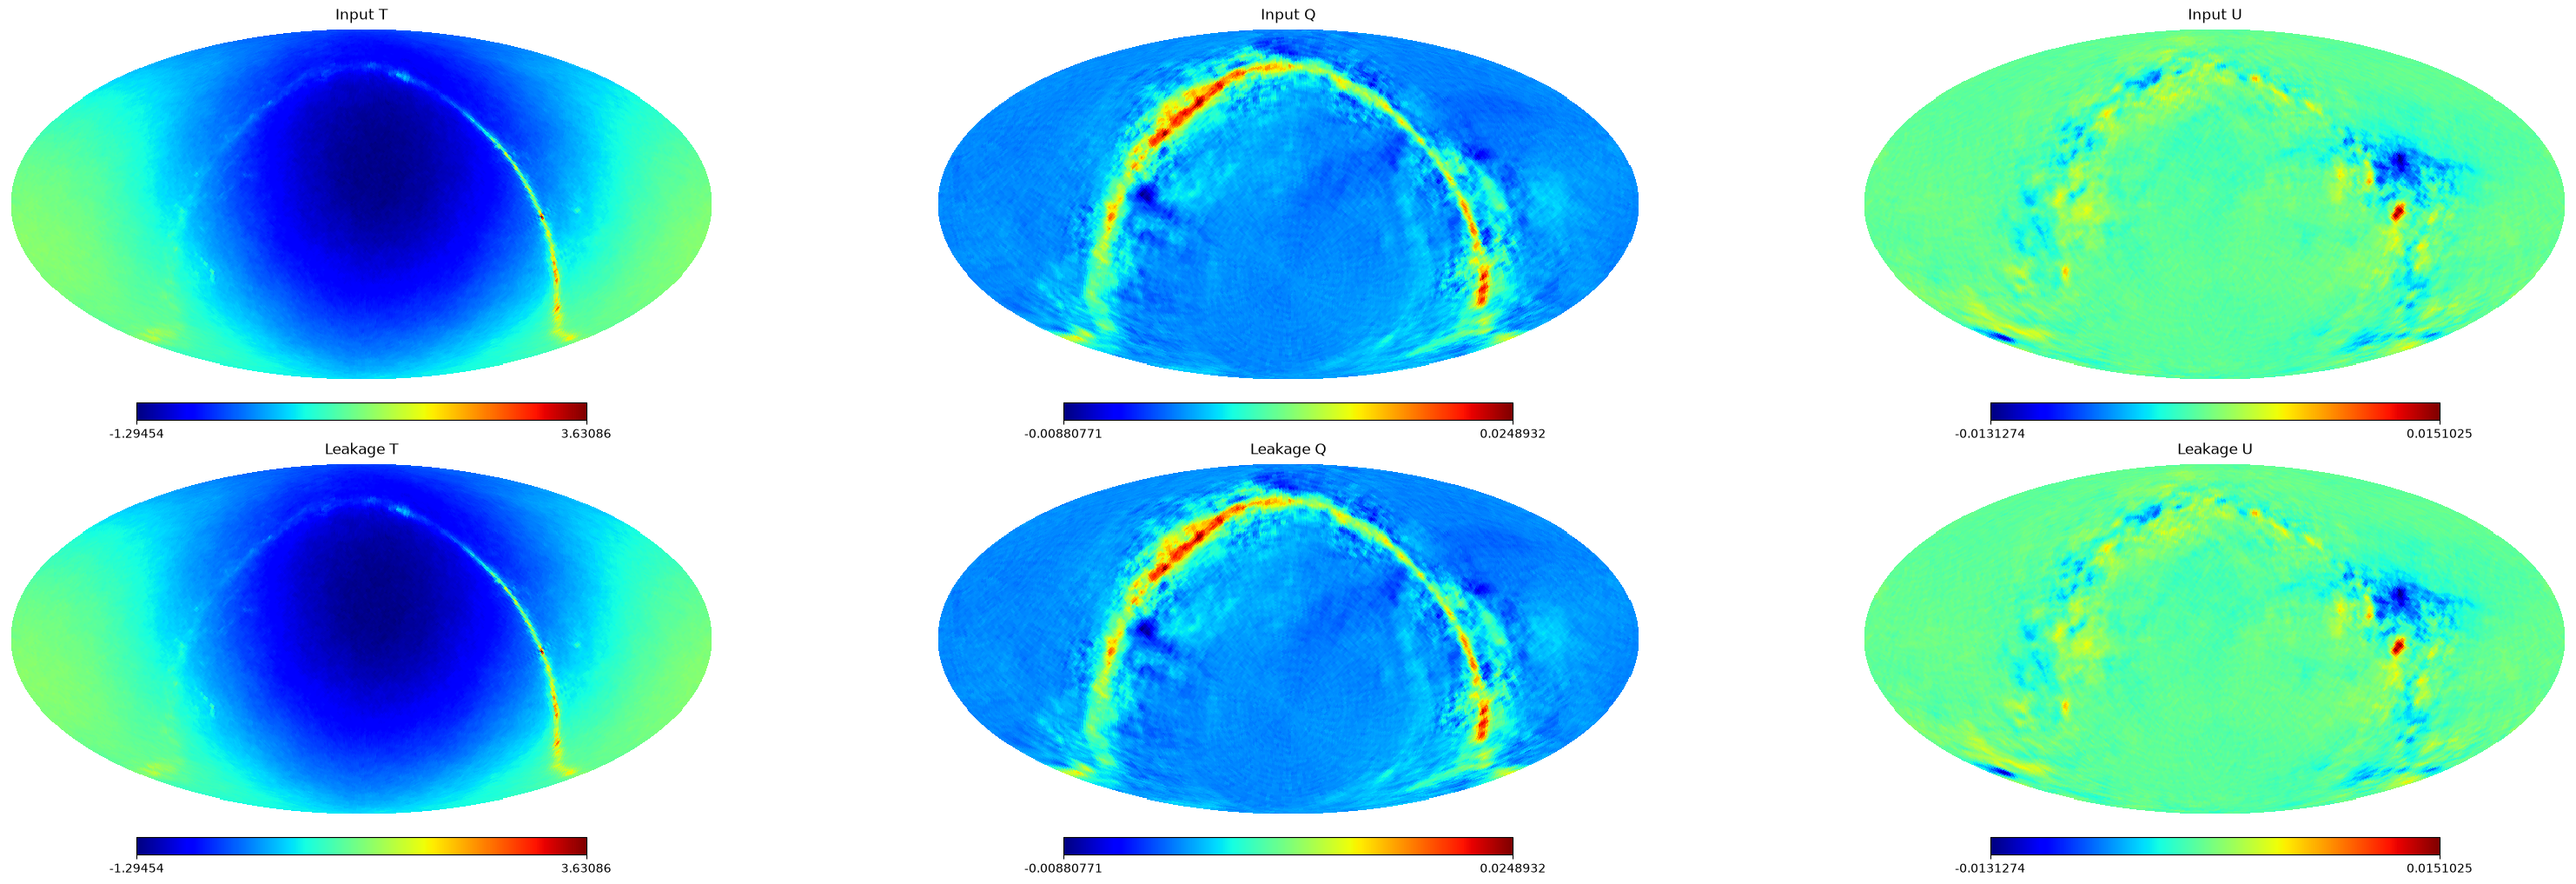

In [16]:
# the input skies are rotated to ecliptic inside lbs.hwp_harmonics module
# so we rotate them in here as well before plotting

#input_maps = np.trapezoid(sky_map.values, frequencies_ghz*1e9, axis=0)/(det.bandwidth_ghz*1e9)
r = hp.Rotator(coord=['G','E'])
input_maps=np.array([r.rotate_map_alms(m) for m in sky_map.values[0]])

plt.figure(figsize=(32, 10))
stokes_parameters = ["T", "Q", "U"]
for i in range(3):
    hp.mollview(
        input_maps[i],
        cmap="jet",
        sub=(2, 3, i + 1),
        title="Input " + stokes_parameters[i],
    )

    hp.mollview(
        output_maps[i],
        cmap="jet",
        sub=(2, 3, i + 4),
        title="Leakage " + stokes_parameters[i],
    )